In [1]:
import numpy as np
import cvxpy as cp
from scipy.spatial.distance import cdist
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.special import gamma
import itertools
import time
import mosek
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes
import pandas as pd

In [2]:
def plot_eval(df, quantiles, df1=None, quantiles1=None,end_ind=61,j=(0,0,0), q = (40,60),K=5, alpha=0.1):
    j1,j2,j3 = j
    # Set up LaTeX rendering
    df = df[K]
    fontsize= 10
    quantiles = quantiles[K]
    q1,q2 = q
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": 11,
        "legend.fontsize": fontsize
    })
    t_range = np.array(df['t'])[(0*end_ind):(1)*end_ind:1]
    plt.figure(figsize=(4.3, 2.1), dpi=300)
    plt.plot(t_range, df['O_eval0'][(j1*end_ind):(j1+1)*end_ind:1], 'b-', linewidth=1, label = "online clustering")

    plt.fill_between(np.array(t_range),y1=np.array(quantiles[q1]['O_eval0'][(j1*end_ind):(j1+1)*end_ind:1]).astype(float),y2=np.array(quantiles[q2]['O_eval0'][(j1*end_ind):(j1+1)*end_ind:1]).astype(float),alpha=alpha, color = 'b')
    plt.plot(t_range, df['MRO_eval0'][(j2*end_ind):(j2+1)*end_ind:1], 'r-', linewidth=1, label = "reclustering")
    plt.fill_between(np.array(t_range),y1=np.array(quantiles[q1]['MRO_eval0'][(j2*end_ind):(j2+1)*end_ind:1]).astype(float),y2=np.array(quantiles[q2]['MRO_eval0'][(j2*end_ind):(j2+1)*end_ind:1]).astype(float),alpha=alpha, color='r')


    # plt.plot(t_range, np.array(df['obj_values'][(j1*end_ind):(j1+1)*end_ind:1])+5*np.array(df['sig_val'][(j1*end_ind):(j1+1)*end_ind:1]), 'b-', linewidth=1, label = "online clustering", marker="v",ms=1.5)
    
    # plt.fill_between(np.array(t_range),y1=np.array(quantiles[q1]['obj_values'][(j1*end_ind):(j1+1)*end_ind:1]).astype(float)+5*np.array(quantiles[q1]['sig_val'][(j1*end_ind):(j1+1)*end_ind:1]).astype(float),y2=np.array(quantiles[q2]['obj_values'][(j1*end_ind):(j1+1)*end_ind:1]).astype(float)+5*np.array(quantiles[q2]['sig_val'][(j1*end_ind):(j1+1)*end_ind:1]).astype(float),alpha=alpha, color = 'b')

    # plt.plot(t_range, np.array(df['MRO_obj_values'][(j2*end_ind):(j2+1)*end_ind:1])+5*np.array(df['MRO_sig_val'][(j2*end_ind):(j2+1)*end_ind:1]), 'r', linewidth=1, label = "reclustering", marker="D",ms=1.5)
    
    # plt.fill_between(np.array(t_range),y1=np.array(quantiles[q1]['MRO_obj_values'][(j2*end_ind):(j2+1)*end_ind:1]).astype(float)+5*np.array(quantiles[q1]['MRO_sig_val'][(j2*end_ind):(j2+1)*end_ind:1]).astype(float),y2=np.array(quantiles[q2]['MRO_obj_values'][(j2*end_ind):(j2+1)*end_ind:1]).astype(float)+5*np.array(quantiles[q2]['MRO_sig_val'][(j2*end_ind):(j2+1)*end_ind:1]).astype(float),alpha=alpha, color='r')


    # plt.plot(t_range, df1['SA_eval1'][(j3*end_ind):(j3+1)*end_ind-1:1], 'g-', linewidth=1, label = "SAA")
    # plt.fill_between(np.array(t_range),y1=np.array(quantiles1[q1]['SA_eval1'][(j3*end_ind)+1:(j3+1)*end_ind:1]).astype(float),y2=np.array(quantiles1[q2]['SA_eval1'][(j3*end_ind)+1:(j3+1)*end_ind:1]).astype(float),alpha=alpha, color='g')
    # plt.ylim([0.008,0.022])
    plt.xlim([1e0,1e4])
    plt.legend()
    plt.xscale("log")
    plt.xlabel(r'Time step $(t)$')
    plt.title(r'Out-of-sample expected value')
    plt.grid(True, alpha=alpha)
    plt.savefig('eval_analysis.pdf', bbox_inches='tight', dpi=300)


In [3]:
def plot_obj(df, quantiles, df1=None, quantiles1=None,end_ind=61,j=(0,0,0), q = (40,60),K=5, alpha=0.1):
    j1,j2,j3 = j
    # Set up LaTeX rendering
    df = df[K]
    fontsize= 10
    quantiles = quantiles[K]
    q1,q2 = q
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": 12,
        "legend.fontsize": fontsize
    })
    t_range = np.array(df['t'])[(0*end_ind):(1)*end_ind:1]
    plt.figure(figsize=(3, 2), dpi=300)
    plt.plot(t_range, df['obj_values'][(j1*end_ind):(j1+1)*end_ind:1], 'b-', linewidth=1, label = "online clustering")

    plt.fill_between(np.array(t_range),y1=np.array(quantiles[q1]['obj_values'][(j1*end_ind):(j1+1)*end_ind:1]).astype(float),y2=np.array(quantiles[q2]['obj_values'][(j1*end_ind):(j1+1)*end_ind:1]).astype(float),alpha=alpha, color = 'b')
    plt.plot(t_range, df['MRO_obj_values'][(j2*end_ind):(j2+1)*end_ind:1], 'r-', linewidth=1, label = "reclustering")
    plt.fill_between(np.array(t_range),y1=np.array(quantiles[q1]['MRO_obj_values'][(j2*end_ind):(j2+1)*end_ind:1]).astype(float),y2=np.array(quantiles[q2]['MRO_obj_values'][(j2*end_ind):(j2+1)*end_ind:1]).astype(float),alpha=alpha, color='r')

    # plt.plot(t_range, df1['SA_eval1'][(j3*end_ind):(j3+1)*end_ind-1:1], 'g-', linewidth=1, label = "SAA")
    # plt.fill_between(np.array(t_range),y1=np.array(quantiles1[q1]['SA_eval1'][(j3*end_ind)+1:(j3+1)*end_ind:1]).astype(float),y2=np.array(quantiles1[q2]['SA_eval1'][(j3*end_ind)+1:(j3+1)*end_ind:1]).astype(float),alpha=alpha, color='g')
    # plt.ylim([0.008,0.022])
    plt.xscale("log")
    plt.legend()
    plt.xlabel(r'Time step $(t)$')
    plt.title(r'In-sample objective value')
    plt.grid(True, alpha=alpha)
    plt.savefig('obj_analysis_T.pdf', bbox_inches='tight', dpi=300)


In [4]:
def plot_computation_times_iter(df, quantiles, df1=None, quantiles1=None, end_ind=61,j=(0,0,0), q = (40,60),K=5, alpha=0.1):
    j1,j2,j3 = j
    df = df[K]
    fontsize= 10
    quantiles = quantiles[K]
    q1,q2 = q
    # Set up LaTeX rendering
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": fontsize
    })
    t_range = np.array(df['t'])[(0*end_ind):(1)*end_ind:1]
    plt.figure(figsize=(3, 2), dpi=300)
    plt.plot(t_range, df['online_time'][(j1*end_ind):(j1+1)*end_ind:1], 'b-', linewidth=1, label = "online clustering")
    plt.plot(t_range, np.array(df['MRO_time'][(j2*end_ind):(j2+1)*end_ind:1]), 'r-', linewidth=1, label = "reclustering")
    plt.fill_between(np.array(t_range),y1=np.array(quantiles[q1]['online_time'][(j1*end_ind):(j1+1)*end_ind:1]).astype(float),y2=np.array(quantiles[q2]['online_time'][(j1*end_ind):(j1+1)*end_ind:1]).astype(float),alpha=alpha, color = 'b')
    plt.fill_between(np.array(t_range),y1=np.array(quantiles[q1]['MRO_time'][(j2*end_ind):(j2+1)*end_ind:1]).astype(float),y2=np.array(quantiles[q2]['MRO_time'][(j2*end_ind):(j2+1)*end_ind:1]).astype(float),alpha=alpha, color = 'r')

    # plt.plot(t_range, df['worst_times'][(j1*end_ind)+1:(j1+1)*end_ind:1], 'b-.', linewidth=1, label = r"online clustering $\hat{H}^K_t$")
    # plt.plot(t_range, df['MRO_worst_times'][(j1*end_ind)+1:(j1+1)*end_ind:1], 'r-.', linewidth=1, label = r"reclustering $\hat{H}^K_t$")
    # plt.fill_between(np.array(t_range),y1=np.array(quantiles[q1]['worst_times'][(j1*end_ind)+1:(j1+1)*end_ind:1]).astype(float),y2=np.array(quantiles[q2]['worst_times'][(j1*end_ind)+1:(j1+1)*end_ind:1]).astype(float),alpha=alpha, color = 'b')
    # plt.fill_between(np.array(t_range),y1=np.array(quantiles[q1]['MRO_worst_times'][(j2*end_ind)+1:(j2+1)*end_ind:1]).astype(float),y2=np.array(quantiles[q2]['MRO_worst_times'][(j2*end_ind)+1:(j2+1)*end_ind:1]).astype(float),alpha=alpha, color = 'r')

    # plt.plot(t_range, df1['DRO_time'][(j3*end_ind)+1:(j3+1)*end_ind:1], color ='black', linewidth=1, label = "DRO")
    # plt.plot(t_range, df1['SA_time'][(j3*end_ind)+1:(j3+1)*end_ind:1], color ='g', linewidth=1, label = "SAA")
    # plt.fill_between(np.array(t_range),y1=np.array(quantiles1[q1]['DRO_time'][(j3*end_ind)+1:(j3+1)*end_ind:1]).astype(float),y2=np.array(quantiles1[q2]['DRO_time'][(j3*end_ind)+1:(j3+1)*end_ind:1]).astype(float),alpha=alpha, color = 'black')
    # plt.fill_between(np.array(t_range),y1=np.array(quantiles1[q1]['SA_time'][(j3*end_ind)+1:(j3+1)*end_ind:1]).astype(float),y2=np.array(quantiles1[q2]['SA_time'][(j3*end_ind)+1:(j3+1)*end_ind:1]).astype(float),alpha=alpha, color = 'g')

    plt.legend()
    plt.xlim([1e0,1e4])
    plt.xlabel(r'Time step $(t)$')
    plt.title(r'Compuation time per iteration (s)')
    plt.grid(True, alpha=0.3)
    # plt.yscale("log")
    plt.xscale("log")
    plt.savefig('time_iters_T.pdf', bbox_inches='tight', dpi=300)

In [5]:
def plot_satisfy(df, df1=None,end_ind=61,j=(0,0,0),K=5):
    # Set up LaTeX rendering
    j1,j2,j3 = j
    df = df[K]
    fontsize= 10
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize,
        "legend.fontsize": fontsize
    })
    t_range = df['t'][(0*end_ind)+1:(1)*end_ind:1]
    plt.figure(figsize=(6, 3), dpi=300)
    plt.plot(t_range, df['O_satisfy1'][(j1*end_ind)+1:(j1+1)*end_ind:1], 'b-', linewidth=1, label = "online clustering")
    plt.plot(t_range, df['MRO_satisfy1'][(j2*end_ind)+1:(j2+1)*end_ind:1], 'r-', linewidth=1, label = "reclustering")


    # plt.plot(t_range, df['O_worst_satisfy1'][(j1*end_ind)+1:(j1+1)*end_ind:1], 'b-.', linewidth=1, label = "online clustering worst")
    plt.plot(t_range, df['MRO_worst_satisfy1'][(j2*end_ind)+1:(j2+1)*end_ind:1], 'r-.', linewidth=1, label = "reclustering worst")
    plt.plot(t_range, df1['SA_satisfy1'][(j3*end_ind):(j3+1)*end_ind-1:1], 'g-', linewidth=1, label = "SAA")
    # plt.plot(t_range, df1['DRO_satisfy1'][(j3*end_ind):(j3+1)*end_ind-1:1], color ='black', linewidth=1, label = "DRO")
    plt.legend()
    plt.xlabel(r'Time step $(t)$')
    plt.ylabel(r'Confidence')
    plt.grid(True, alpha=0.3)
    plt.savefig('prob_analysis.pdf', bbox_inches='tight', dpi=300)


In [6]:
def plot_dists(df, quantiles, end_ind=61, q = (40,60),K=5, alpha=0.1):
    j1,j2 = (0,0)
    df = df[K]
    fontsize= 11
    quantiles = quantiles[K]
    q1,q2 = q
    # Set up LaTeX rendering
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 12,
        "legend.fontsize": 9
        
    })
    t_range = np.array(df['t'])[(0*end_ind)+1:(1)*end_ind:1]
    plt.figure(figsize=(3, 2), dpi=300)
    plt.plot(t_range, df['mean_val'][(j1*end_ind)+1:(j1+1)*end_ind:1], 'b:', linewidth=1, label = r"online clustering $D_1(K,t)$")
    plt.plot(t_range, df['MRO_mean_val'][(j2*end_ind)+1:(j2+1)*end_ind:1], 'r:', linewidth=1, label = r"reclustering $D_1(K,t)$")
    plt.plot(t_range, df['square_val'][(j1*end_ind)+1:(j1+1)*end_ind:1], 'b-', linewidth=1, label = r"online clustering $D_2(K,t)$")
    plt.plot(t_range, df['MRO_square_val'][(j2*end_ind)+1:(j2+1)*end_ind:1], 'r', linewidth=1, label = r"reclustering $D_2(K,t)$")
    


    plt.fill_between(np.array(t_range),y1=np.array(quantiles[q1]['mean_val'][(j1*end_ind)+1:(j1+1)*end_ind:1]).astype(float),y2=np.array(quantiles[q2]['mean_val'][(j1*end_ind)+1:(j1+1)*end_ind:1]).astype(float),alpha=alpha, color = 'b')
    plt.fill_between(np.array(t_range),y1=np.array(quantiles[q1]['MRO_mean_val'][(j2*end_ind)+1:(j2+1)*end_ind:1]).astype(float),y2=np.array(quantiles[q2]['MRO_mean_val'][(j2*end_ind)+1:(j2+1)*end_ind:1]).astype(float),alpha=alpha, color = 'r')
    plt.fill_between(np.array(t_range),y1=np.array(quantiles[q1]['square_val'][(j1*end_ind)+1:(j1+1)*end_ind:1]).astype(float),y2=np.array(quantiles[q2]['square_val'][(j1*end_ind)+1:(j1+1)*end_ind:1]).astype(float),alpha=alpha, color = 'b')
    plt.fill_between(np.array(t_range),y1=np.array(quantiles[q1]['MRO_square_val'][(j2*end_ind)+1:(j2+1)*end_ind:1]).astype(float),y2=np.array(quantiles[q2]['MRO_square_val'][(j2*end_ind)+1:(j2+1)*end_ind:1]).astype(float),alpha=alpha, color = 'r')

    plt.legend(loc = 'center right',  bbox_to_anchor=(1, 0.6))
    plt.xlabel(r'Time step $(t)$')
    plt.title(r'Clustering distances')
    plt.grid(True, alpha=0.3)
    plt.yscale("log")
    plt.savefig('dist_conv.pdf', bbox_inches='tight', dpi=300)

In [14]:
def plot_dists(df, quantiles, end_ind=61, j = (0,0), q = (40,60),K=5, alpha=0.1,ylim = None):
    j1,j2 = j
    df = df[K]
    fontsize= 11
    quantiles = quantiles[K]
    q1,q2 = q
    # Set up LaTeX rendering
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 9
        
    })
    t_range = np.array(df['t'])[(0*end_ind):(1)*end_ind:1]
    plt.figure(figsize=(4.3, 2.1), dpi=300)
    plt.plot(t_range, df['mean_val'][(j1*end_ind):(j1+1)*end_ind:1], 'b:', linewidth=1, label = r"$W^K_{t,1}$")
    plt.plot(t_range, df['MRO_mean_val'][(j2*end_ind):(j2+1)*end_ind:1], 'r:', linewidth=1)

    plt.plot(t_range, 5*np.array(df['sig_val'][(j1*end_ind):(j1+1)*end_ind:1]), 'b-.', linewidth=1, label = r"$\Phi^K_t$")
    plt.plot(t_range, 5*np.array(df['MRO_sig_val'][(j2*end_ind):(j2+1)*end_ind:1]), 'r-.', linewidth=1)

    plt.plot(t_range, df['square_val'][(j1*end_ind):(j1+1)*end_ind:1], 'b-', linewidth=0.5, label = r"$(D^K_{t,2})^2$")
    plt.plot(t_range, df['MRO_square_val'][(j2*end_ind):(j2+1)*end_ind:1], 'r', linewidth=0.5)


    plt.fill_between(np.array(t_range),y1=np.array(quantiles[q1]['mean_val'][(j1*end_ind):(j1+1)*end_ind:1]).astype(float),y2=np.array(quantiles[q2]['mean_val'][(j1*end_ind):(j1+1)*end_ind:1]).astype(float),alpha=alpha, color = 'b')
    plt.fill_between(np.array(t_range),y1=np.array(quantiles[q1]['MRO_mean_val'][(j2*end_ind):(j2+1)*end_ind:1]).astype(float),y2=np.array(quantiles[q2]['MRO_mean_val'][(j2*end_ind):(j2+1)*end_ind:1]).astype(float),alpha=alpha, color = 'r')
    plt.fill_between(np.array(t_range),y1=np.array(quantiles[q1]['square_val'][(j1*end_ind):(j1+1)*end_ind:1]).astype(float),y2=np.array(quantiles[q2]['square_val'][(j1*end_ind):(j1+1)*end_ind:1]).astype(float),alpha=alpha, color = 'b')
    plt.fill_between(np.array(t_range),y1=np.array(quantiles[q1]['MRO_square_val'][(j2*end_ind):(j2+1)*end_ind:1]).astype(float),y2=np.array(quantiles[q2]['MRO_square_val'][(j2*end_ind):(j2+1)*end_ind:1]).astype(float),alpha=alpha, color = 'r')

    plt.fill_between(np.array(t_range),y1=5*np.array(quantiles[q1]['sig_val'][(j1*end_ind):(j1+1)*end_ind:1]).astype(float),y2=5*np.array(quantiles[q2]['sig_val'][(j1*end_ind):(j1+1)*end_ind:1]).astype(float),alpha=alpha, color = 'b')
    plt.fill_between(np.array(t_range),y1=5*np.array(quantiles[q1]['MRO_sig_val'][(j2*end_ind):(j2+1)*end_ind:1]).astype(float),y2=5*np.array(quantiles[q2]['MRO_sig_val'][(j2*end_ind):(j2+1)*end_ind:1]).astype(float),alpha=alpha, color = 'r')

    plt.legend()
    plt.xlabel(r'Time step $(t)$')
    plt.title(r'Clustering distances')
    plt.grid(True, alpha=0.3)
    plt.xscale("log")
    # plt.yscale("log")
    plt.xlim([1e0,1e4])
    plt.ylim(ylim)
    plt.savefig('dist_conv.pdf', bbox_inches='tight', dpi=300)

In [8]:
T=10001
R = 30
K_list = [15,25]
eps_init = [0.005,0.0048,0.0015]
M = len(eps_init)
quant_list = [25,75]
foldername = '/Users/irina.wang/Desktop/Princeton/Project2/mro_mpc/portfolio_exp_50/T'+str(T-1)+'R'+str(10)+'/'
folderout = '/Users/irina.wang/Desktop/Princeton/Project2/mro_mpc/portfolio_exp_50/T'+str(T-1)+'/'
# setup MRO dfs
def setup_dfs(init = False):
    if init:
        quantiles = {}
        for K in K_list:
            dfs_list = []
            for r in range(R):
                newdf = pd.read_csv(foldername + 'df_' + 'K'+str(K)+'R'+ str(r) +'.csv')
                dfs_list.append(newdf)
            df1 = dfs_list[0]
            quantiles[K] = {}
            for quant in quant_list:
                quantiles[K][quant] = pd.DataFrame(index=df1.index, columns=df1.columns)
                # Calculate quantiles for each entry
                for i in range(len(df1.index)):
                    for j in range(len(df1.columns)):
                        values = [dfs_list[k].iloc[i, j] for k in range(len(dfs_list))]
                        quantiles[K][quant].iloc[i, j] = np.percentile(values, quant)
                quantiles[K][quant].to_csv(folderout+'quantiles_'+ str(quant)+'K'+str(K)+'.csv')
            sum_df = dfs_list[0].copy()
            for dfs in dfs_list[1:]:
                sum_df = sum_df.add(dfs, fill_value=0)
            sum_df = sum_df/(R)
            sum_df.to_csv(folderout+'df_'+ 'K'+str(K)+'.csv')
    df = {}
    quantiles = {}
    for K in K_list:
        df[K] = pd.read_csv(folderout+'df_' + 'K'+str(K)+'.csv')
        quantiles[K] = {}
        for quant in quant_list:
            quantiles[K][quant] = pd.read_csv(folderout+'quantiles_'+ str(quant)+'K'+str(K)+'.csv')
    return df, quantiles

In [9]:
df, quantiles = setup_dfs(init = True)

In [10]:
returns = pd.read_csv('/Users/irina.wang/Desktop/Princeton/Project2/mro_mpc/portfolio_time/sp500_synthetic_returns.csv').to_numpy()[:,1:]

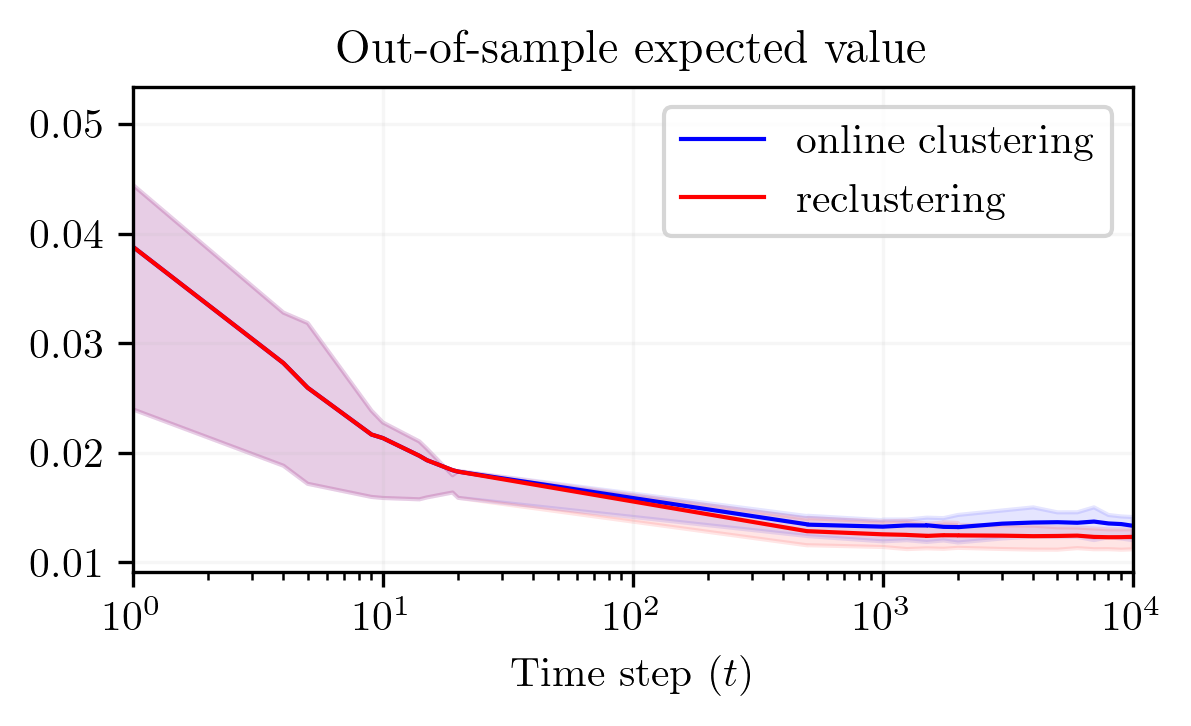

In [11]:
# K = K_list[4]
# plot_eval(df,quantiles,df[0],quantiles[0],j=(1,7,0),K=15,q=(25,75), dro=True,end_ind = 201)

K = 25
plot_eval(df,quantiles,None,None,j=(1,1,0),K=25,q=(25,75),end_ind = 30)

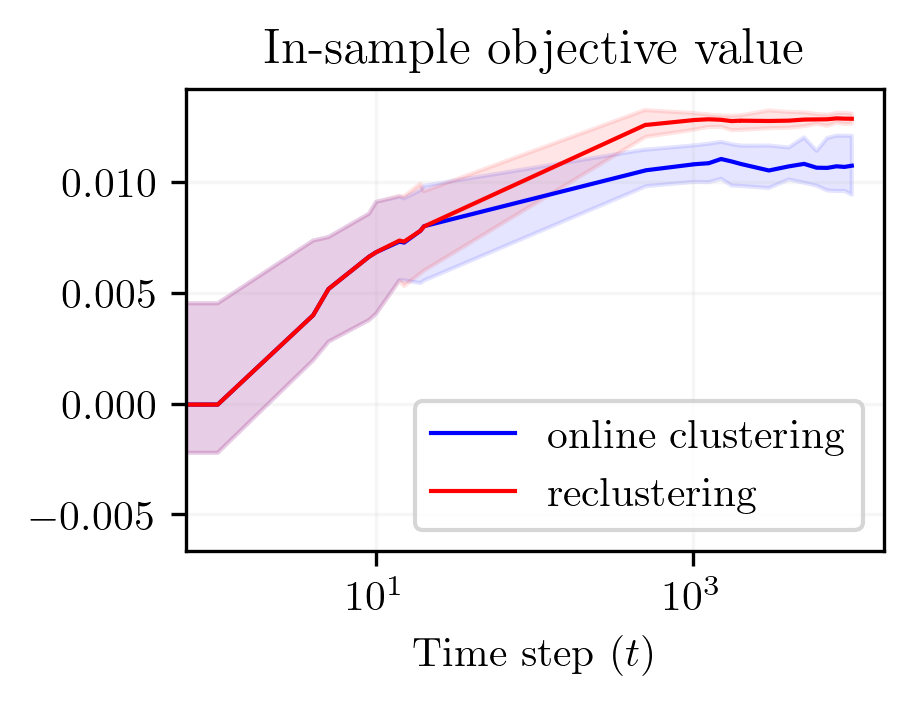

In [12]:
# K = K_list[4]
# plot_eval(df,quantiles,df[0],quantiles[0],j=(1,7,0),K=15,q=(25,75), dro=True,end_ind = 201)

K = 15
plot_obj(df,quantiles,None,None,j=(1,1,0),K=15,q=(25,75),end_ind = 30)

In [13]:
def tofloatarray(string):
    string = string.replace('[', '').replace(']', '')
    return np.fromstring(string, sep=' ')

def pad_array(array, K):
    num_zeros = K - len(array)
    return np.concatenate((array, np.zeros(num_zeros)))

dfw = pd.read_csv(folderout+'df_weights.csv')
kweights = np.vstack([tofloatarray(dfw['weights'][j]) for j in range(201) ])
MRO_kweights = np.vstack([tofloatarray(dfw['MRO_weights'][j]) for j in range(201) ])

plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 12,
        "legend.fontsize": 9
        
    })
plt.figure(figsize=(3, 1.9), dpi=300)
for j in range(15):
  plt.plot(dfw['t'][:101:1],kweights[:,j][::1], linewidth = 1)
plt.xlabel(r'Time step $(t)$')
plt.title(r'Cluster weights')
plt.grid(True, alpha=0.3)
plt.savefig('weights.pdf', bbox_inches='tight', dpi=300)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/irina.wang/Desktop/Princeton/Project2/mro_mpc/portfolio_exp_50/T10000/df_weights.csv'

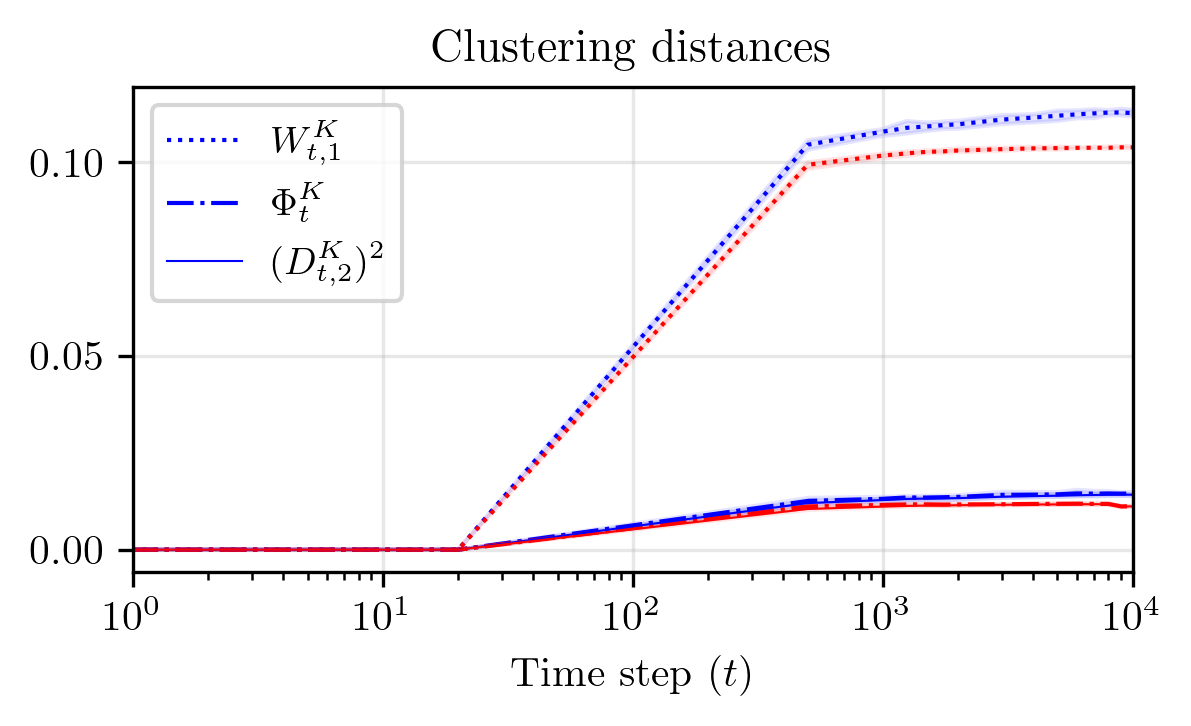

In [15]:
plot_dists(df,quantiles,q = (25,75),j = (1,1), end_ind=30,K=25,ylim = None)

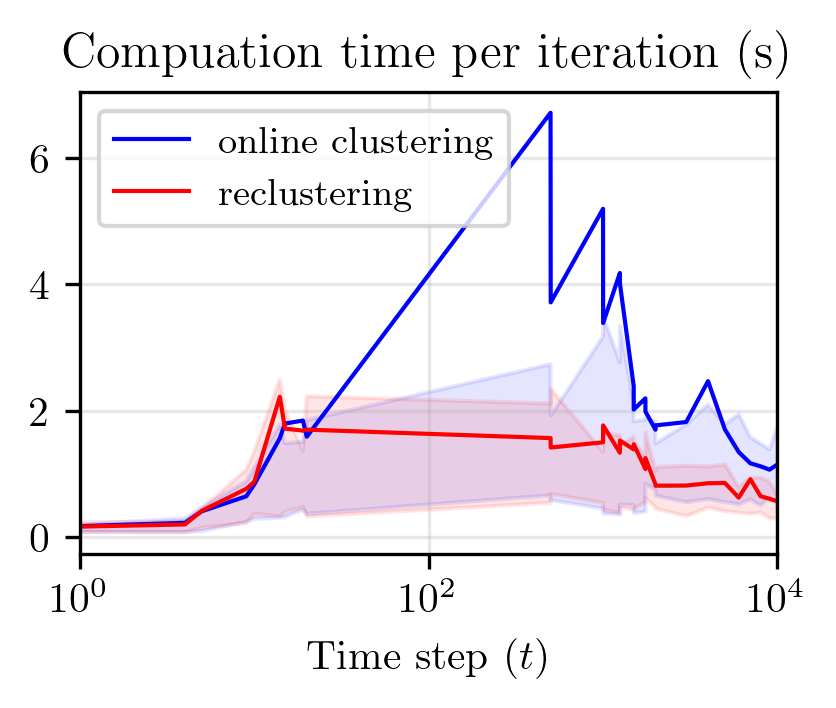

In [88]:
plot_computation_times_iter(df,quantiles,df[15],quantiles[15],j=(1,1,0),K=25,q=(25,75), end_ind = 30)